<a href="https://colab.research.google.com/github/HeetBhatt18/Pandas_Project/blob/main/Pandas_data_analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [3]:
# Data cleaning

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/police.csv")

df.head()

,stop_date,stop_time,county_name,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,2005-01-02,01:55,NaN,M,1985.0,20.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
1,2005-01-18,08:15,NaN,M,1965.0,40.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
2,2005-01-23,23:15,NaN,M,1972.0,33.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
3,2005-02-20,17:15,NaN,M,1986.0,19.0,White,Call for Service,Other,False,NaN,Arrest Driver,True,16-30 Min,False
4,2005-03-14,10:00,NaN,F,1984.0,21.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91741 entries, 0 to 91740
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   stop_date           91741 non-null  object 
 1   stop_time           91741 non-null  object 
 2   county_name         0 non-null      float64
 3   driver_gender       86406 non-null  object 
 4   driver_age_raw      86414 non-null  float64
 5   driver_age          86120 non-null  float64
 6   driver_race         86408 non-null  object 
 7   violation_raw       86408 non-null  object 
 8   violation           86408 non-null  object 
 9   search_conducted    91741 non-null  bool   
 10  search_type         3196 non-null   object 
 11  stop_outcome        86408 non-null  object 
 12  is_arrested         86408 non-null  object 
 13  stop_duration       86408 non-null  object 
 14  drugs_related_stop  91741 non-null  bool   
dtypes: bool(2), float64(3), object(10)
memory usage: 9.3+

In [5]:
# check if there are null values
df.isnull().sum()

,0
stop_date,0
stop_time,0
county_name,91741
driver_gender,5335
driver_age_raw,5327
driver_age,5621
driver_race,5333
violation_raw,5333
violation,5333
search_conducted,0


In [6]:
# delete unnecessary columns
df = df.drop(columns=["county_name","search_type"])

In [7]:
df.head(10)

,stop_date,stop_time,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,2005-01-02,01:55,M,1985.0,20.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False
1,2005-01-18,08:15,M,1965.0,40.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False
2,2005-01-23,23:15,M,1972.0,33.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False
3,2005-02-20,17:15,M,1986.0,19.0,White,Call for Service,Other,False,Arrest Driver,True,16-30 Min,False
4,2005-03-14,10:00,F,1984.0,21.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False
5,2005-03-23,09:45,M,1982.0,23.0,Black,Equipment/Inspection Violation,Equipment,False,Citation,False,0-15 Min,False
6,2005-04-01,17:30,M,1969.0,36.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False
7,2005-06-06,13:20,F,1986.0,19.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False
8,2005-07-13,10:15,M,1970.0,35.0,Black,Speeding,Speeding,False,Citation,False,0-15 Min,False
9,2005-07-13,15:45,M,1970.0,35.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False


In [8]:
# Filling the null values in numeric columns with median
def fill_null(df):
    numeric_columns = df.select_dtypes(include=['float64'])

    df[numeric_columns.columns] = numeric_columns.apply(lambda col: col.fillna(col.median()))
    return df

df = fill_null(df)

In [9]:
# Fill null values in lremaining columns with the mode

# print(df['driver_gender'].value_counts())  # M    62895, F    23511
df['driver_gender']= df['driver_gender'].fillna('M')

#print(df['driver_race'].value_counts())  # White       62158  (max)
df['driver_race']= df['driver_race'].fillna('White')

# print(df['violation_raw'].value_counts())  # Speeding   48463  (max)
df['violation_raw']= df['violation_raw'].fillna('Speeding')

df['violation']= df['violation'].fillna('Speeding')

# print(df['stop_outcome'].value_counts())  # Citation  77006  (max)
df['stop_outcome']= df['stop_outcome'].fillna('Citation')

# print(df['is_arrested'].value_counts())
df['is_arrested']= df['is_arrested'].fillna('FALSE')

# print(df['stop_duration'].value_counts())  # 0-15 Min     69543  (max)
df['stop_duration']= df['stop_duration'].fillna('0-15 Min')

# if date with wrong format
df["stop_date"] = pd.to_datetime(df["stop_date"])

In [10]:
df.isna().sum()

,0
stop_date,0
stop_time,0
driver_gender,0
driver_age_raw,0
driver_age,0
driver_race,0
violation_raw,0
violation,0
search_conducted,0
stop_outcome,0


In [11]:
df.to_csv('Cleaned_Police_data.csv', index=False)

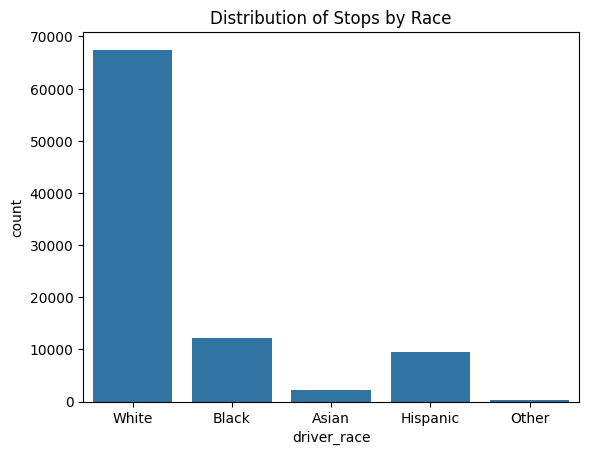

In [12]:
# Distribution by Race
sns.countplot(data=df, x='driver_race')
plt.title("Distribution of Stops by Race")
plt.show()

/tmp/ipykernel_3414/2327669568.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='driver_gender', palette='pastel')


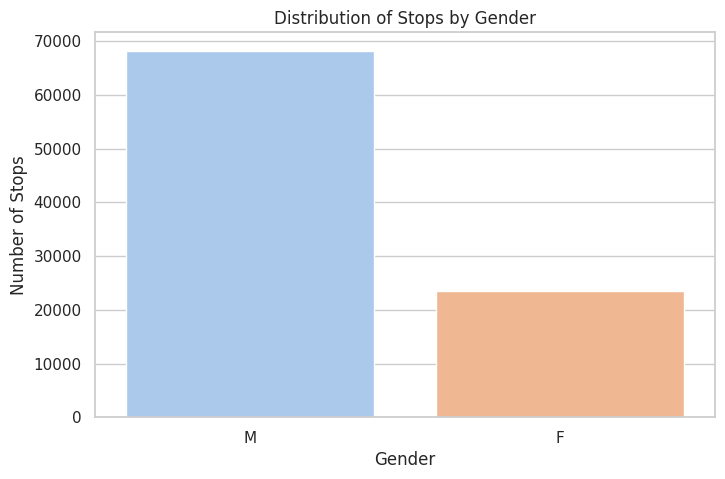

In [13]:
# Set the style for seaborn
sns.set(style='whitegrid')

# Distribution of Stops by Gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='driver_gender', palette='pastel')
plt.title('Distribution of Stops by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Stops')
plt.show()

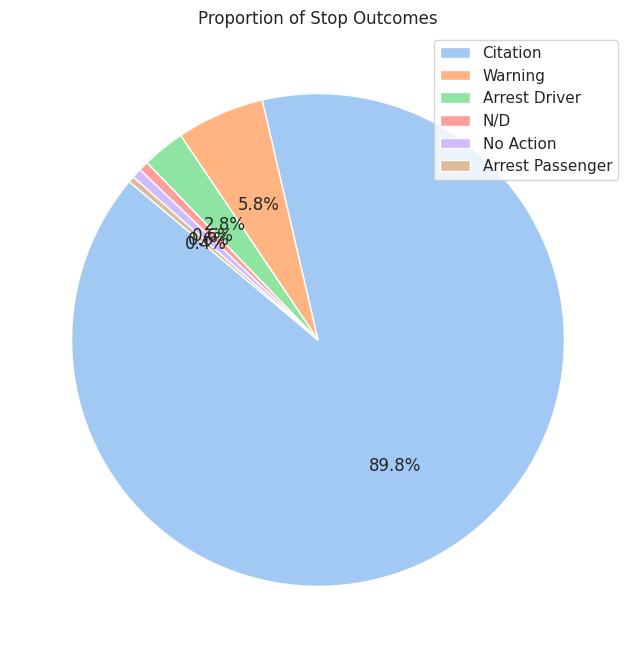

In [14]:
#Proportion of Stop Outcomes
outcome_counts = df['stop_outcome'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(outcome_counts, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Stop Outcomes')
plt.legend(labels=outcome_counts.index)
plt.show()

/tmp/ipykernel_3414/982147863.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='violation', palette='Set2')


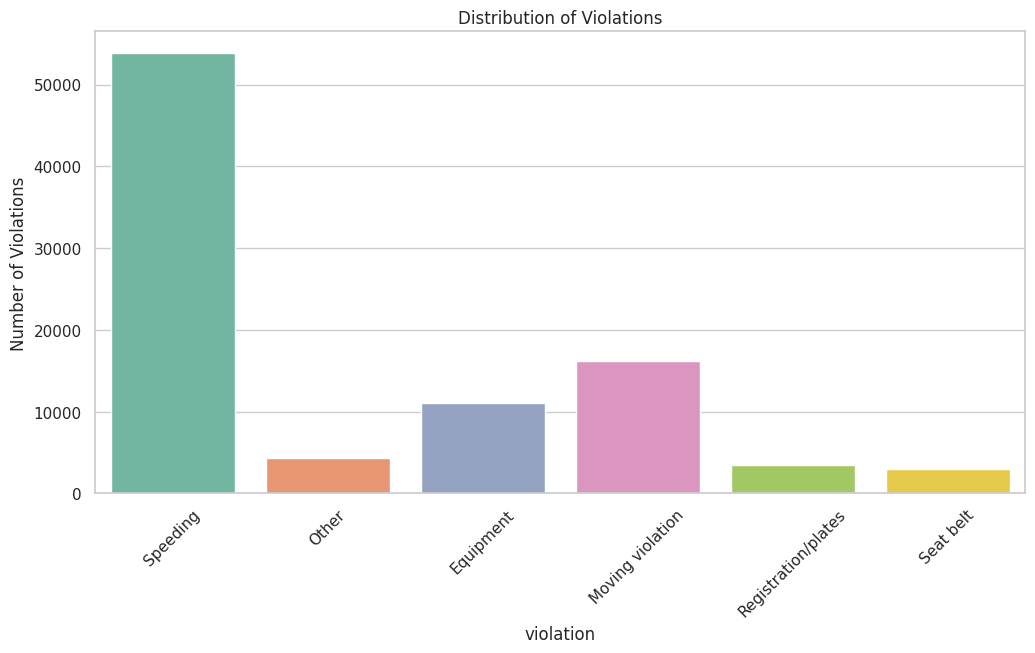

In [15]:
# Distribution of Violations
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='violation', palette='Set2')
plt.title('Distribution of Violations')
plt.xticks(rotation=45)
plt.ylabel('Number of Violations')
plt.show()

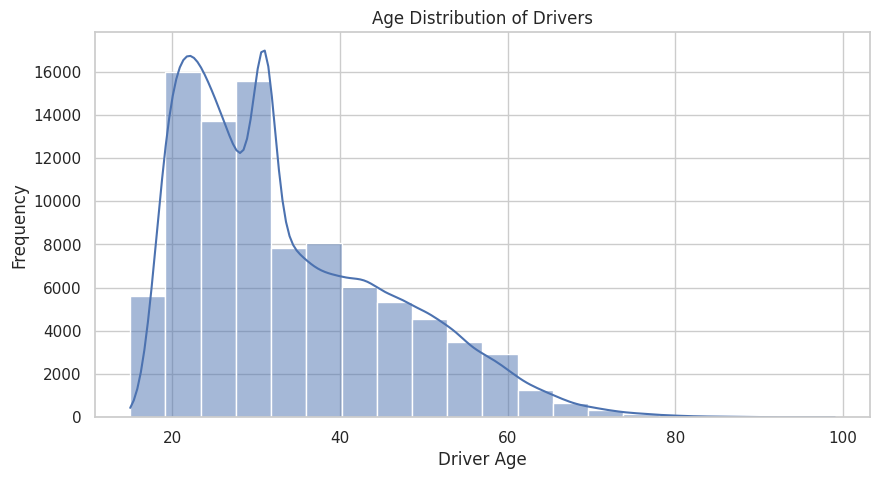

In [16]:
# Age Distribution of Drivers
plt.figure(figsize=(10, 5))
sns.histplot(df['driver_age'], bins=20, kde=True)
plt.title('Age Distribution of Drivers')
plt.xlabel('Driver Age')
plt.ylabel('Frequency')
plt.show()

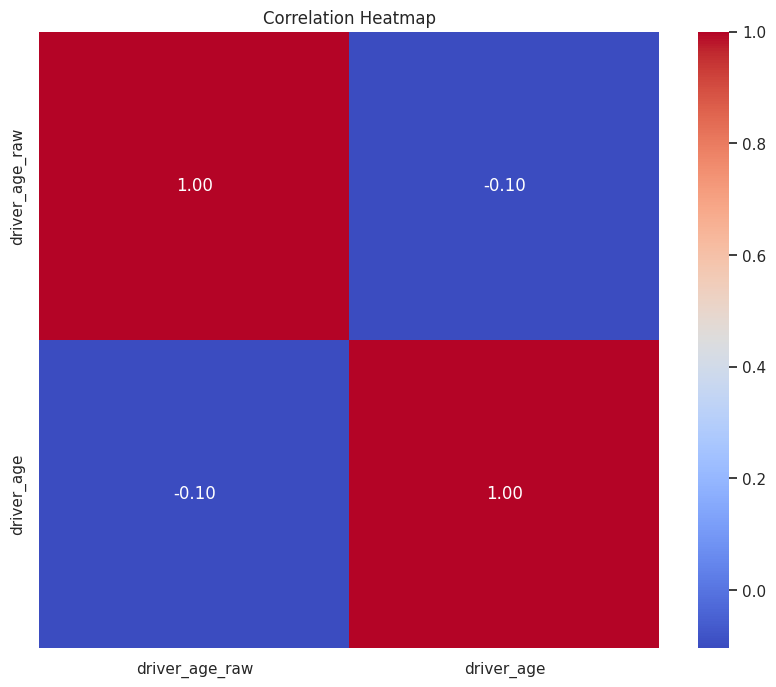

In [17]:
# Correlation Between Numerical Variables
# Filter numeric columns only
numeric_data = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()